# Relación entre talla y valor de las órdenes

En este notebook analizo la relación entre la talla de los productos y el valor de las órdenes. Comparo el promedio y la mediana del importe de las órdenes para las diferentes tallas, utilizando un boxplot para observar la distribución y posibles diferencias entre ellas. También reviso la cantidad de observaciones y los valores faltantes para determinar si las comparaciones son confiables.

El objetivo es identificar si el valor de las órdenes presenta patrones diferentes según la talla y entender qué podría significar esta relación para el análisis de ventas.

In [1]:
from pathlib import Path
import pandas as pd

rutas_dataset = [
    Path('../data/Amazon_Sales.csv'),
    Path('data/Amazon_Sales.csv')
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)
if ruta_dataset is None:
    raise FileNotFoundError('No se encontró data/Amazon_Sales.csv')

df = pd.read_csv(ruta_dataset)
print('Dimensiones del dataset:', df.shape)
print('Tipos de Size y Amount:')
print(df[['Size', 'Amount']].dtypes)
print('\nValores faltantes:')
print(df[['Size', 'Amount']].isna().sum())
print('\nTallas observadas:')
print(df['Size'].value_counts(dropna=False))

Dimensiones del dataset: (128975, 22)
Tipos de Size y Amount:
Size       object
Amount    float64
dtype: object

Valores faltantes:
Size      0
Amount    0
dtype: int64

Tallas observadas:
Size
M       22711
L       22132
XL      20876
XXL     18096
S       17090
3XL     14816
XS      11161
6XL       738
5XL       550
4XL       427
Free      378
Name: count, dtype: int64


Filas originales: 128975
Filas válidas para el análisis: 128975
Talla faltante o vacía: 0
Amount faltante o no numérico: 0
Amount infinito: 0
Amount negativo: 0

Estadísticas por talla (solo tallas de la secuencia solicitada):


,numero_ordenes,promedio,mediana
Size,,,
XS,11161,629.19,622.86
S,17090,621.95,599.00
M,22711,612.34,597.00
L,22132,598.00,573.00
XL,20876,597.10,563.00
XXL,18096,587.77,545.00
3XL,14816,618.06,582.00
4XL,427,783.26,798.00
5XL,550,773.01,798.00


Excluidas del boxplot por no ser tallas de la secuencia: ['FREE'] (378 filas; se conservaron durante la limpieza).
No hay tallas con menos de 30 observaciones.


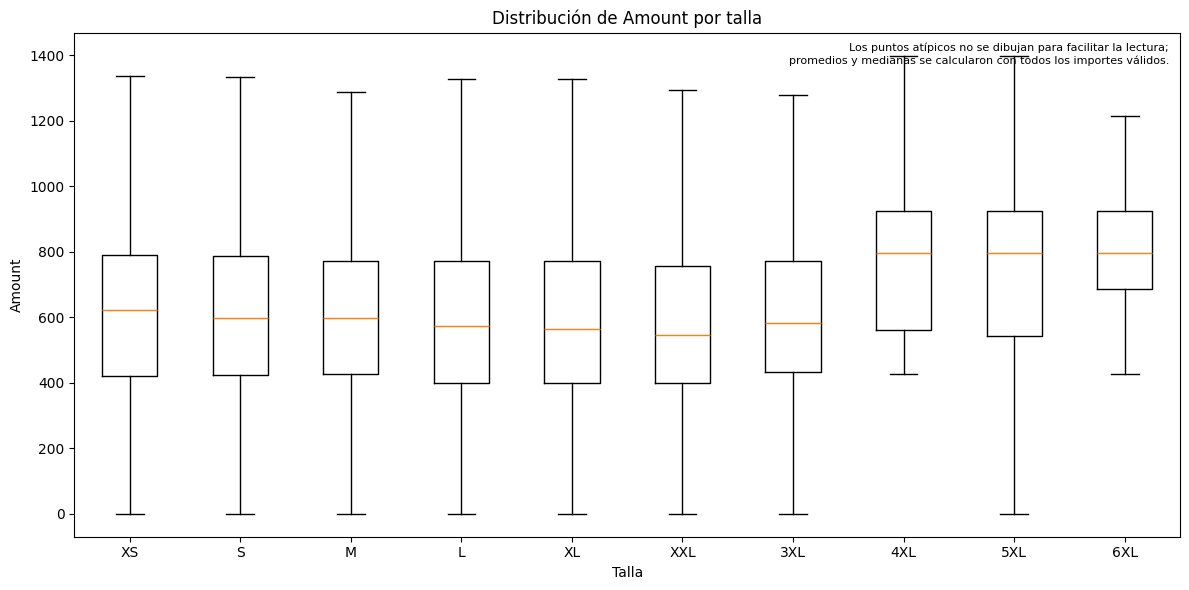

La mediana más alta es de 4XL (798.00); la más baja es de XXL (545.00).
El boxplot y las medianas permiten describir diferencias entre tallas, pero no se ha realizado una prueba estadística para afirmar que sean significativas. El importe de una orden también puede depender de otros factores, como el tipo de producto o la cantidad comprada.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

orden_tallas = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL']

analisis = df[['Size', 'Amount']].copy()
analisis['Size'] = analisis['Size'].astype('string').str.strip().str.upper()
analisis['Amount'] = pd.to_numeric(analisis['Amount'], errors='coerce')

faltan_talla = analisis['Size'].isna() | analisis['Size'].eq('')
faltan_importe = analisis['Amount'].isna()
importe_finito = np.isfinite(analisis['Amount'])
importe_no_negativo = analisis['Amount'].ge(0)
mascara_valida = (
    ~faltan_talla
    & ~faltan_importe
    & importe_finito
    & importe_no_negativo
)
analisis_limpio = analisis.loc[mascara_valida].copy()

print('Filas originales:', len(analisis))
print('Filas válidas para el análisis:', len(analisis_limpio))
print('Talla faltante o vacía:', int(faltan_talla.sum()))
print('Amount faltante o no numérico:', int(faltan_importe.sum()))
print('Amount infinito:', int((~importe_finito & ~faltan_importe).sum()))
print('Amount negativo:', int((~importe_no_negativo & importe_finito & ~faltan_importe).sum()))

estadisticas = (
    analisis_limpio.groupby('Size')['Amount']
    .agg(numero_ordenes='count', promedio='mean', mediana='median')
)
estadisticas_tallas = estadisticas.reindex(orden_tallas).dropna(subset=['numero_ordenes'])
tallas_fuera_orden = sorted(set(estadisticas.index) - set(orden_tallas))

print('\nEstadísticas por talla (solo tallas de la secuencia solicitada):')
display(estadisticas_tallas.round(2))
if tallas_fuera_orden:
    filas_fuera_orden = int(analisis_limpio['Size'].isin(tallas_fuera_orden).sum())
    print(
        f'Excluidas del boxplot por no ser tallas de la secuencia: {tallas_fuera_orden} '
        f'({filas_fuera_orden:,} filas; se conservaron durante la limpieza).'
    )

umbral_pocas_observaciones = 30
tallas_pocas = estadisticas_tallas.loc[
    estadisticas_tallas['numero_ordenes'] < umbral_pocas_observaciones
]
if tallas_pocas.empty:
    print(f'No hay tallas con menos de {umbral_pocas_observaciones} observaciones.')
else:
    print(f'Advertencia: estas tallas tienen menos de {umbral_pocas_observaciones} observaciones:')
    display(tallas_pocas.round(2))
    print('Sus promedios y medianas pueden ser menos estables que los de grupos grandes.')

tallas_muestra_menor = estadisticas_tallas.loc[
    estadisticas_tallas['numero_ordenes'] < 1_000
]
if not tallas_muestra_menor.empty:
    print('\nTallas con menos de 1,000 observaciones (muestra menor frente a las demás):')
    display(tallas_muestra_menor[['numero_ordenes']])
    print('Estas tallas tienen menos datos que XS–3XL, así que sus distribuciones son menos precisas para comparar.')

valores_por_talla = [
    analisis_limpio.loc[analisis_limpio['Size'] == talla, 'Amount'].to_numpy()
    for talla in estadisticas_tallas.index
]
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(valores_por_talla, tick_labels=estadisticas_tallas.index, showfliers=False)
ax.set_title('Distribución de Amount por talla')
ax.set_xlabel('Talla')
ax.set_ylabel('Amount')
fig.text(
    0.5, 0.01,
    'Sin puntos atípicos para facilitar la lectura; las estadísticas incluyen todos los importes válidos.',
    ha='center', va='bottom', fontsize=9
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

if not estadisticas_tallas.empty:
    talla_mediana_mayor = estadisticas_tallas['mediana'].idxmax()
    talla_mediana_menor = estadisticas_tallas['mediana'].idxmin()
    mediana_mayor = estadisticas_tallas.loc[talla_mediana_mayor, 'mediana']
    mediana_menor = estadisticas_tallas.loc[talla_mediana_menor, 'mediana']
    print(
        f'La mediana más alta es de {talla_mediana_mayor} ({mediana_mayor:,.2f}); '
        f'la más baja es de {talla_mediana_menor} ({mediana_menor:,.2f}).'
    )
    print(
        'Descriptivamente, 4XL–6XL muestran medianas superiores a XS–3XL en este dataset; '
        'sin embargo, los grupos 4XL–6XL tienen muestras mucho menores. No se realizó una '
        'prueba estadística, así que esto no basta para afirmar una diferencia significativa '
        'o generalizable. Amount también puede depender del tipo de producto y de la cantidad comprada.'
    )